# Data-Driven Churn Prediction: Bridging the Activation Gap with Machine Learning

---

## Project Overview: Predictive Modeling & Behavioral Segmentation

### Objective
The goal of this project is to implement a proactive student churn detection system and segment users based on their learning archetypes. This phase transitions from a descriptive "Activation Gap" analysis into an automated, data-driven system for targeted retention.

### Background & Context
This analysis is built upon the key findings of the initial product research:
* **Activation Gap Discovery**: 40.7% of users abandon the course before attempting a single task.
* **Friction Zones**: Primary drop-off points are concentrated within the first 10 steps (Orders 1–11).
* **The Goal**: Develop a model capable of detecting these patterns early, enabling the platform to intervene through personalized triggers and re-boarding strategies.



### Data Description: Engineered Feature Set
The analysis was conducted on a processed dataset (`user_metrics.csv`) containing **19,234 unique users**. Features were aggregated to capture specific behavioral patterns:

**Behavioral & Pace Metrics:**
* `active_days` — Total days with recorded activity.
* `median_gap_days` — Median interval between sessions (consistency metric).
* `steps_per_day` / `score_per_day` — Average content consumption and points earned per active day.
* `activity_frequency` / `activity_frequency_practical` — Intensity of general and practical interactions.

**Performance & Progress:**
* `total_score` / `progress_percent_score` — Cumulative points and course completion rate.
* `submission_correct_rate` — Success ratio of practical task attempts.
* `n_submissions` — Total volume of practical attempts (persistence metric).

**Status & Metadata:**
* `is_in_progress` — Original system flag for active status.
* `certificate` — Indicator of course completion (Score ≥ 75).
* `last_timestamp` — Timestamp used to calculate the refined target.
* `is_extreme` — Flag for the top 5% of users (outliers) for specialized handling.

---

### Data Engineering & Refinement
To ensure high model fidelity, the following data improvements were implemented:

* **Target Correction (The 30-Day Rule)**: It was discovered that the initial system logic (`is_in_progress`) overestimated the active student base by **15.4%** (1,888 vs. 1,596 actual retained users). We implemented a strict **30-day inactivity threshold** to define the "Ground Truth" for churn.
* **Feature Synthesis (`effort_efficiency`)**: A custom metric was created (ratio of progress to total submissions) to detect learner frustration vs. efficiency.

---

### Key ML Findings
* **The Returners Paradox**: Corrected the classification of **Cluster 3 ("The Returners")**. Identified **292 "Ghost Users"** whose actual churn rate was **90.9%**, contrary to the 18.2% suggested by raw system flags.
* **Predictive Dominance**: **Achievement (`score_per_day`)** and **Behavioral Style (`cluster`)** proved to be significantly stronger predictors of churn than simple login frequency.
* **Model Performance**: By applying a **10:1 class weight**, the Random Forest model successfully identified loyal students (Class 0) in a highly imbalanced environment, reducing the detection error for this class to **44.7%**.



---

### Analysis Structure
1. **Environment Setup & Data Integration**: Data loading and initial feature audit.
2. **Exploratory Data Analysis (EDA) for ML**: Correlation analysis to handle multicollinearity.
3. **Unsupervised Learning (Clustering)**: Application of **K-means** to identify 4 distinct behavioral archetypes.
4. **Target Variable Refinement**: Addressing system bias and establishing "Ground Truth" labels.
5. **Supervised Learning (Random Forest)**: Training the classification model with balanced techniques.
6. **Feature Importance & Interpretation**: Analyzing **MeanDecreaseAccuracy** and **Gini** to identify success drivers.

---

### Assumptions & Limitations
**Assumptions:**
* **Temporal Proxy**: 30 days of inactivity is assumed to be a sufficient indicator of terminal churn.
* **Label Fidelity**: The refined target `is_churned_refined` is treated as the "Ground Truth" for model training.
* **Temporal Relevance**: Behavioral patterns from 2015–2018 are assumed to be representative, as psychological churn triggers (frustration, loss of rhythm) remain stable over time.

**Limitations:**
* **Right-Censoring Guard**: Users on a very long hiatus might still be misclassified as churned.
* **Static Features**: The model utilizes aggregated totals rather than the real-time velocity of actions.

### Strategic Conclusion
The model proves that **Score Stagnation** is the primary leading indicator of churn. To maximize retention, the platform must focus on maintaining the user’s "Success Loop" within their specific behavioral cluster, rather than simply monitoring platform visits.

---

In [1]:
# Environment Setup
if (!require(pacman)) install.packages("pacman")

Загрузка требуемого пакета: pacman

Warning message:
"пакет 'pacman' был собран под R версии 4.4.3"


In [2]:
pacman::p_load(data.table, here, dplyr, corrplot, knitr, caret, ggplot2, randomForest)

---

 ## Data Loading 

In [3]:
user_features <- fread("../data/user_metrics.csv")

In [4]:
set.seed(42)
user_features %>% sample_n(10)

user_id,n_passed_all,n_passed_practical,n_discovered_all,n_viewed_all,n_started_practical,n_submissions,active_days,course_duration,median_gap_days,⋯,activity_frequency_practical,steps_per_day,last_timestamp,last_step_id,is_extreme,total_score,score_per_day,progress_percent_score,certificate,is_in_progress
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dttm>,<int>,<lgl>,<int>,<dbl>,<dbl>,<int>,<int>
26132,197,76,197,894,101,248,67,749.738,2.0,⋯,0.331,2.940,2017-07-04 13:06:56,33417,TRUE,88,1.313,100.000,1,0
12897,49,16,51,92,21,48,5,11.680,1.5,⋯,4.110,9.800,2018-02-11 03:22:11,32215,FALSE,15,3.000,17.045,0,0
1709,13,0,14,37,0,0,3,6.698,3.5,⋯,0.000,4.333,2015-11-01 10:02:16,32950,FALSE,0,0.000,0.000,0,0
21593,28,9,28,75,9,33,2,2.049,2.0,⋯,16.104,14.000,2016-09-07 10:07:33,32950,FALSE,8,4.000,9.091,0,0
12266,1,0,1,1,0,0,1,1.000,0.0,⋯,0.000,1.000,2016-08-12 17:50:17,33537,FALSE,0,0.000,0.000,0,0
14289,1,0,1,1,0,0,1,1.000,0.0,⋯,0.000,1.000,2018-04-01 15:05:47,33977,FALSE,0,0.000,0.000,0,0
18703,192,75,192,736,126,144,42,1020.304,4.0,⋯,0.141,4.571,2018-04-09 12:50:42,32202,TRUE,88,2.095,100.000,1,0
19989,1,0,1,1,0,0,1,1.000,0.0,⋯,0.000,1.000,2017-11-23 11:40:24,32815,FALSE,0,0.000,0.000,0,0
23313,1,0,1,1,0,0,1,1.000,0.0,⋯,0.000,1.000,2017-10-16 12:03:17,32243,FALSE,0,0.000,0.000,0,0


In [5]:
glimpse(user_features)

Rows: 19,234
Columns: 22
$ user_id                      <int> 1, 2, 3, 5, 7, 8, 9, 11, 14, 16, 17, 18, …
$ n_passed_all                 <int> 0, 9, 87, 11, 1, 84, 3, 0, 3, 196, 5, 2, …
$ n_passed_practical           <int> 0, 2, 29, 2, 0, 9, 0, 0, 0, 76, 0, 0, 0, …
$ n_discovered_all             <int> 1, 9, 91, 11, 1, 109, 3, 1, 4, 196, 6, 3,…
$ n_viewed_all                 <int> 1, 10, 192, 12, 1, 156, 4, 1, 9, 651, 13,…
$ n_started_practical          <int> 0, 2, 30, 4, 0, 37, 0, 1, 1, 108, 1, 0, 0…
$ n_submissions                <int> 0, 2, 52, 4, 0, 30, 0, 0, 1, 183, 2, 0, 0…
$ active_days                  <int> 1, 2, 7, 2, 1, 2, 1, 1, 1, 21, 1, 1, 1, 3…
$ course_duration              <dbl> 1.000, 56.060, 118.323, 390.083, 1.000, 9…
$ median_gap_days              <dbl> 0, 56, 2, 390, 0, 10, 0, 0, 0, 2, 0, 0, 0…
$ submission_correct_rate      <dbl> 0.000, 1.000, 0.558, 0.500, 0.000, 0.300,…
$ activity_frequency           <dbl> 1.000, 0.178, 1.623, 0.031, 1.000, 15.609…
$ activity_freq

In [6]:
summary(user_features)

    user_id       n_passed_all    n_passed_practical n_discovered_all
 Min.   :    1   Min.   :  0.00   Min.   : 0.00      Min.   :  0.00  
 1st Qu.: 6636   1st Qu.:  1.00   1st Qu.: 0.00      1st Qu.:  1.00  
 Median :13358   Median :  8.00   Median : 1.00      Median :  9.00  
 Mean   :13364   Mean   : 33.81   Mean   :11.25      Mean   : 35.85  
 3rd Qu.:20074   3rd Qu.: 39.00   3rd Qu.: 9.00      3rd Qu.: 42.00  
 Max.   :26798   Max.   :198.00   Max.   :76.00      Max.   :198.00  
  n_viewed_all      n_started_practical n_submissions      active_days    
 Min.   :    0.00   Min.   :  0.00      Min.   :   0.00   Min.   :  1.00  
 1st Qu.:    1.00   1st Qu.:  0.00      1st Qu.:   0.00   1st Qu.:  1.00  
 Median :   12.00   Median :  2.00      Median :   1.00   Median :  1.00  
 Mean   :   95.13   Mean   : 16.06      Mean   :  26.46   Mean   :  6.09  
 3rd Qu.:   89.00   3rd Qu.: 15.00      3rd Qu.:  24.00   3rd Qu.:  6.00  
 Max.   :32778.00   Max.   :721.00      Max.   :1051.00   Ma

---

## Behavioral Segmentation & Feature Engineering

In [7]:
# Define base features for clustering and churn
features_clustering_base <- c(
    "active_days", 
    "median_gap_days", 
    "submission_correct_rate", 
    "activity_frequency", 
    "activity_frequency_practical", 
    "steps_per_day", 
    "score_per_day")

features_churn_base <- c(
    features_clustering_base,
    "progress_percent_score", 
    "n_submissions")

In [8]:
# Check only features_churn because it contains features_clustering
# Here and further will be used only features_churn_base because it consists all features from features_clustering_base 
colSums(is.na(user_features[, ..features_churn_base]))

active_days              median_gap_days 
                           0                            0 
     submission_correct_rate           activity_frequency 
                           0                            0 
activity_frequency_practical                steps_per_day 
                           0                            0 
               score_per_day       progress_percent_score 
                           0                            0 
               n_submissions 
                           0

In [9]:
# Calculate Parson correlation
corr_matrix_base <- cor(user_features[, ..features_churn_base], use = "pairwise.complete.obs")         

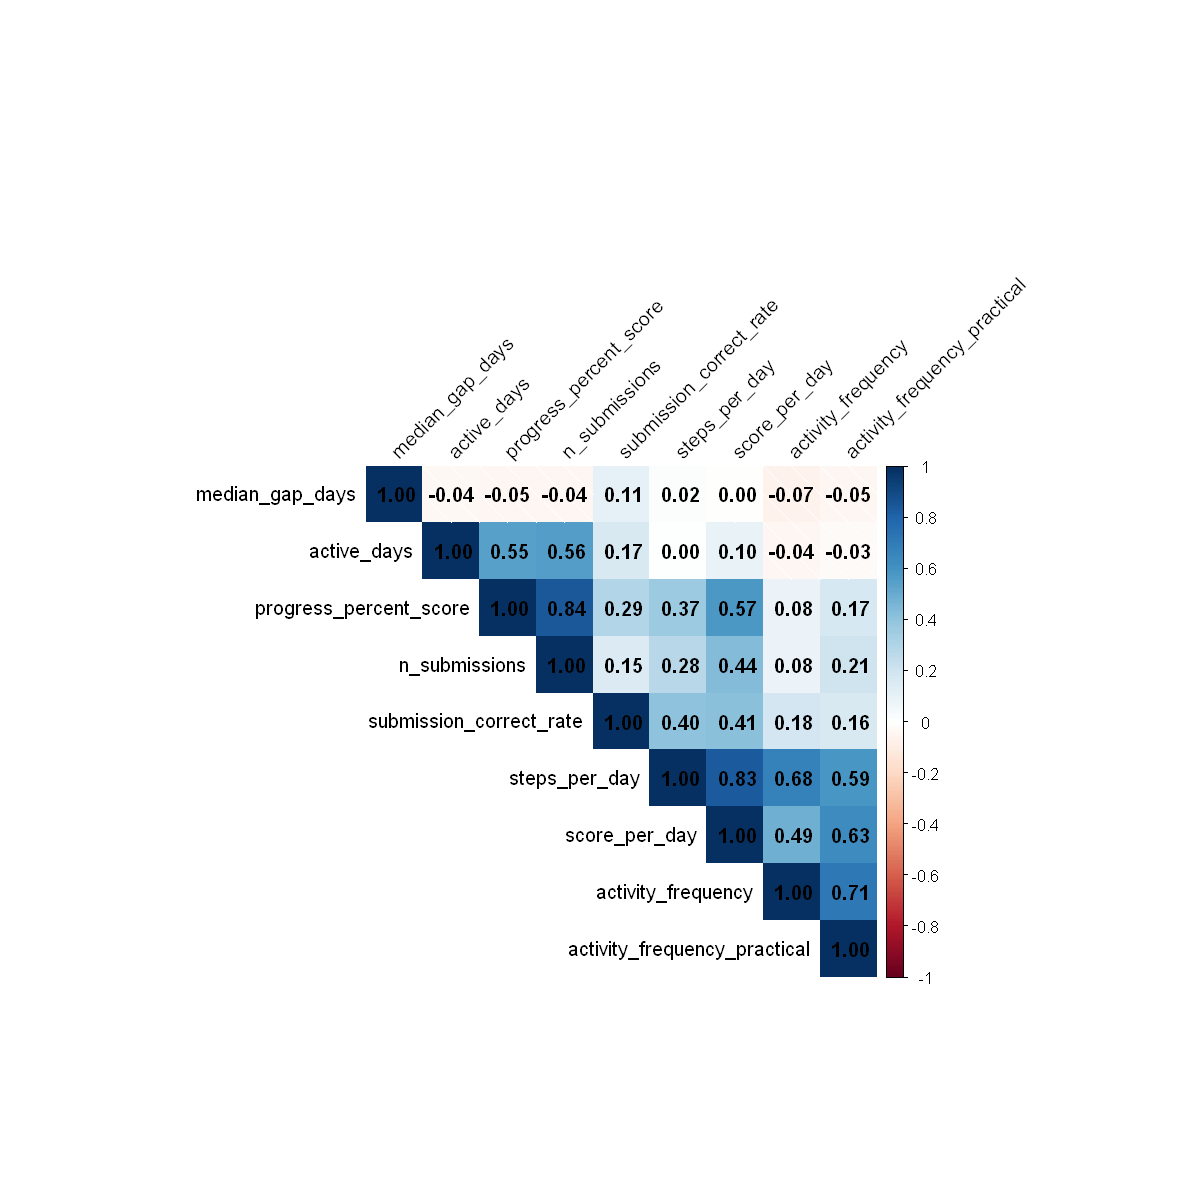

In [10]:
# Visualize correlations to detect multicollinearit
options(repr.plot.width = 10, repr.plot.height = 10)

corrplot(corr_matrix_base, 
         method = "shade",     
         type = "upper",         
         order = "hclust",      
         addCoef.col = "black",  
         tl.col = "black",      
         tl.srt = 45)  

**Correlation Base Matrix Analysis & Feature Selection**

A feature audit for clustering and churn prediction models was conducted based on the Pearson correlation matrix.

 - Key Insights:
   1. **Multicollinearity in Learning Pace**: A strong correlation exists between `steps_per_day` and `score_per_day` (0.83). To prevent redundancy in the clustering model, only `steps_per_day` is retained as the primary pace metric.
   2. **Effort vs. Achievement**: Despite the high correlation between `progress_percent_score` and `n_submissions` (0.85), both features are essential for churn prediction. They help distinguish between high-efficiency learners and those struggling with task completion.
   3. **Uniqueness of Learning Rhythm**: The `median_gap_days` feature shows nearly zero correlation with other metrics (r ≈ 0), making it a vital independent variable for identifying consistency patterns.
   4. **Solution Quality**: `submission_correct_rate` is weakly linked to overall progress (0.29), allowing the model to identify "trial-and-error" behavioral groups regardless of their current course stage.

 - Strategic Decisions:
   * **For Clustering (Style)**: Only relative behavioral features are selected (`median_gap_days`, `submission_correct_rate`, `steps_per_day`, `activity_frequency_practical`, `active_days`). Cumulative totals (scores) are excluded to ensure clusters represent *behavioral style* rather than *course progress*.
   * **For Prediction (Churn)**: An expanded feature set is used, including `progress_percent_score` and `n_submissions`. A synthetic feature, `effort_efficiency` (score-to-submission ratio), will be introduced to detect user frustration.


In [11]:
# Create "Effort Efficiency" synthetic feature
# Logic: Represents ROI of student efforts (progress percentage gained per submission).
# n_submissions + 1: Standard zero-division guard for users with no submissions.
# Smoothing: Acts as a simple regularizer to prevent extreme outliers for early-stage users.
user_features[, effort_efficiency := progress_percent_score / (n_submissions + 1)]

In [12]:
# Define final features for clustering and churn
features_clustering_final <- setdiff(features_clustering_base, "score_per_day")

features_churn_final <- c(
    features_clustering_final, 
    "n_submissions",
    "score_per_day",           
    "progress_percent_score",  
    "effort_efficiency"        
)

In [13]:
# Calculate Parson correlation with final features
corr_matrix_final <- cor(user_features[, ..features_churn_final], use = "pairwise.complete.obs")

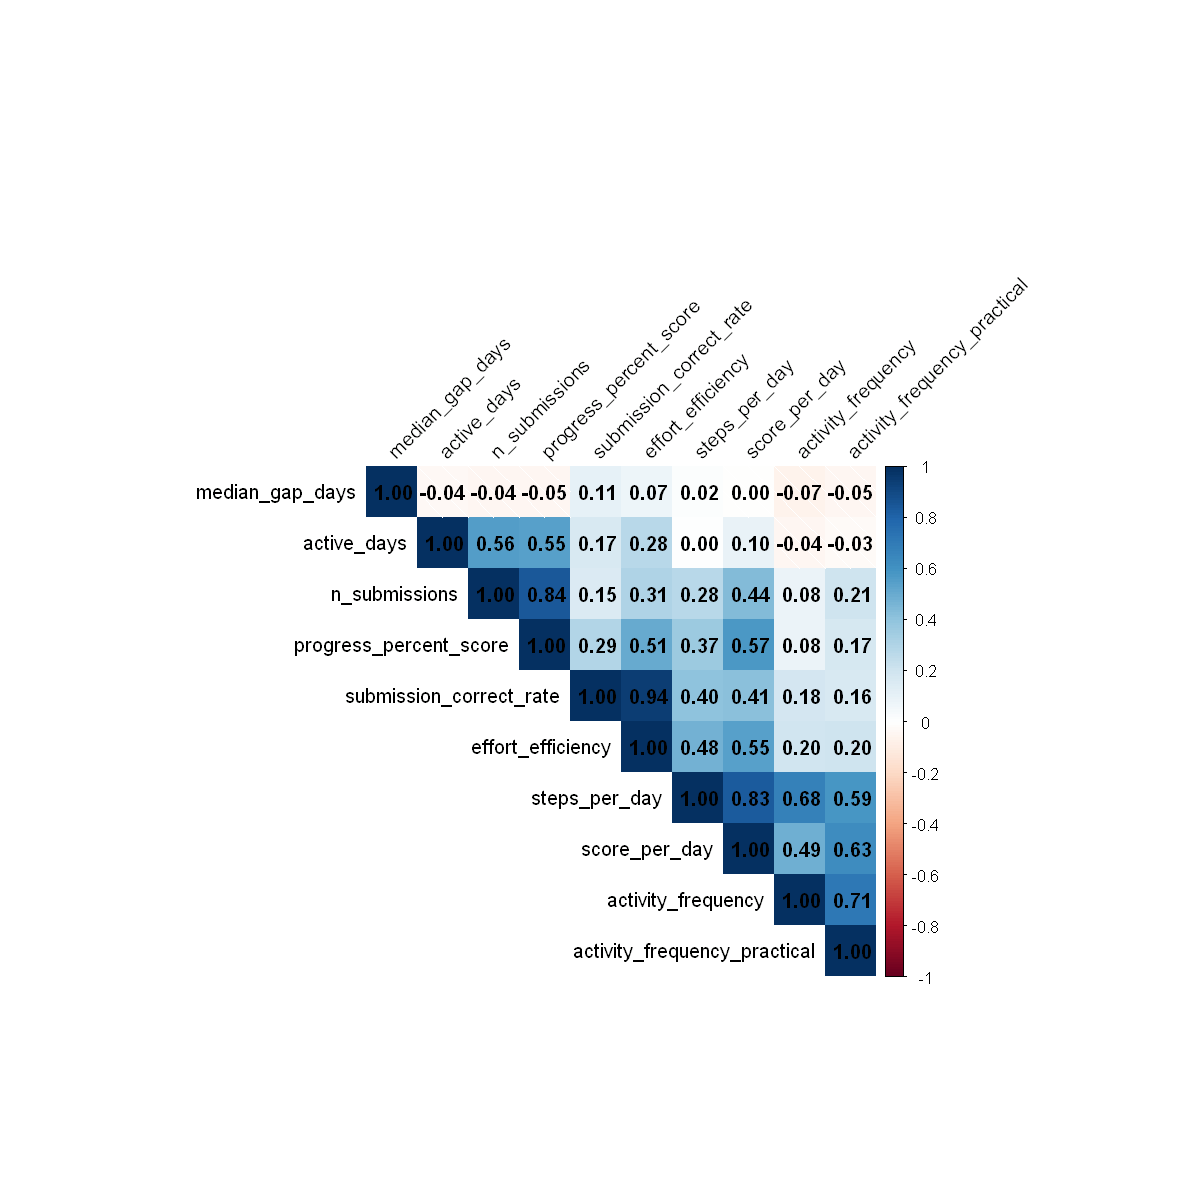

In [14]:
# Visualize correlations to detect multicollinearit with finel features
options(repr.plot.width = 10, repr.plot.height = 10)

corrplot(corr_matrix_final,
        method = "shade",
        type = "upper",
        order = "hclust",
        addCoef.col = "black",
        tl.col = "black",
        tl.srt = 45)

**Final Correlation Matrix Analysis & Feature Refinement**

Following the introduction of the synthetic effort_efficiency feature, a final correlation audit was performed. These results guided the optimization of feature sets for both clustering and churn prediction.

**Key Observations**:
 
   - **Handling High Multicollinearity ($r = 0.94$)**: 
   
     - A critical correlation was identified between `submission_correct_rate` and `effort_efficiency`. 
      - For the churn prediction model, we prioritize `effort_efficienc` as it demonstrates a stronger relationship with overall progress ($0.51$ vs $0.28$) and captures the "Return on Effort" more effectively.
   - **The Persistence Logic (Retention of `n_submissions`)**: 
    
     - Despite a high correlation with progress metrics ($r = 0.84$), `n_submissions` is deliberately retained in the final churn model. 
      - From a behavioral science perspective, the raw volume of attempts is a key indicator of student persistence. 
      - Keeping both allows the model to detect "Struggling Persisters" (high submissions, low progress) — a high-risk churn profile that a single efficiency metric might overlook.
      
   - **Synthetic Feature Performance**: 
   
     - The correlation between `effort_efficiency` and `progress_percent_score` stands at $0.51$. This is significantly lower than the original progress-to-submissions correlation ($0.84$), proving that the new feature provides unique, non-redundant information about learner behavior.
     
   - **Pace-based Grouping ($r = 0.83$)**: 
   
     - A strong link remains between `steps_per_day` and `score_per_day`. For clustering, only `steps_per_day` is used to avoid over-weighting the "speed" of progression and focus strictly on the style of content consumption.
     
   - **Independence of Learning Rhythm**: 
   
     - The `median_gap_days` feature continues to show near-zero correlation with all other metrics, remaining a unique and vital indicator of learning consistency (rhythm).

**Final Feature Sets:**

| Model Task | Selected Features |
| :--- | :--- |
| **Clustering (Behavioral Style)** | `active_days`, `median_gap_days`, `submission_correct_rate`, `activity_frequency_practical`, `steps_per_day` |
| **Churn Prediction (Outcome)** | *All Clustering features* + `n_submissions`, `effort_efficiency`, `progress_percent_score`, `score_per_day` |

In [15]:
# After completing the correlation audit and sanity checks, 
# we re-declare the final feature sets to ensure they are locked for the modeling phase.
features_clustering_final <- c(
    "active_days", 
    "median_gap_days", 
    "submission_correct_rate", 
    "activity_frequency_practical", 
    "steps_per_day"
)

features_churn_final <- c(
    features_clustering_final, 
    "n_submissions",
    "score_per_day", 
    "progress_percent_score", 
    "effort_efficiency"
)

In [16]:
# Filtering out 'extreme' users to focus on the general student population
# K-means is highly sensitive to outliers; removing them ensures representative centroids
user_features_clean <- user_features[is_extreme == FALSE]

In [17]:
# Scaling the data (Z-score normalization) 
# Essential for K-means as features have different units (days vs. percentages)
scaled_data <- scale(user_features_clean[, ..features_clustering_final])

---

## Behavioral Segmentation: Defining User Archetypes

### Optimal Cluster Discovery (Elbow Method)

In [18]:
# Set seed for reproducibility: K-means starts with random centroids, 
# so we fix the seed to get consistent results every time we run the code.
set.seed(42)

In [19]:
# Calculate WSS (Within-Cluster Sum of Squares) for different K values
wss <- sapply(1:10, function(k) {
  kmeans(scaled_data, centers = k, nstart = 20, iter.max = 50)$tot.withinss
})

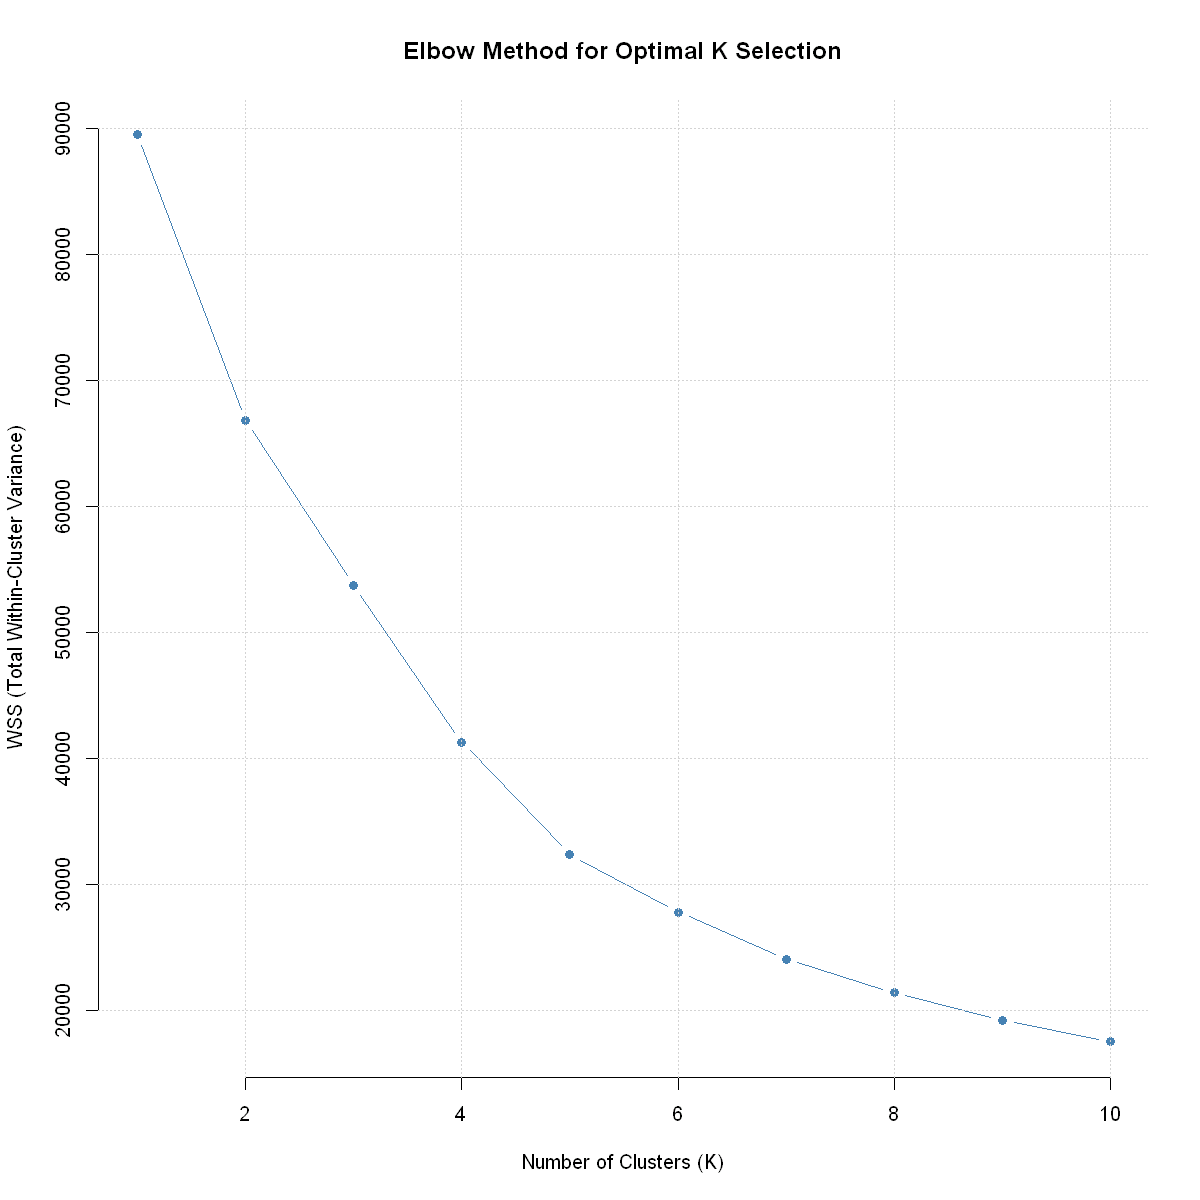

In [20]:
# Plotting the results to visually identify the 'elbow' point
plot(1:10, wss, type = "b", pch = 19, frame = FALSE, 
     xlab = "Number of Clusters (K)", 
     ylab = "WSS (Total Within-Cluster Variance)", 
     main = "Elbow Method for Optimal K Selection", 
     col = "steelblue")

grid()

**Optimal Cluster Selection**

To segment users based on their learning behavior, the **Elbow Method** was applied. We evaluated the Within-Cluster Sum of Squares (WSS) for a range of clusters from $K=1$ to $K=10$.

-  **Analysis of the Plot**:

   - **WSS Reduction**: The most dramatic drop in WSS occurs between 1 and 3 clusters, indicating that the data naturally forms distinct behavioral groups.
   - **The "Elbow" Point**: A visible bend in the curve appears at $K=3$. However, the transition to $K=4$ still provides a significant reduction in variance, capturing more nuanced differences in user engagement.
   - **Plateau Effect**: From $K=5$ onwards, the curve begins to flatten out (plateau). Adding further clusters yields diminishing returns, as it doesn't significantly improve the compactness of the clusters.

- **Justification for Choosing K=4**:

   - **Mathematical Stability**: It represents the optimal trade-off point where the model captures maximum variance before the gains become marginal.
  - **Behavioral Depth**: While 3 clusters might only show "High/Medium/Low" performance, 4 clusters allow us to identify specific sub-types, such as "Sprinters" (fast learners) versus "Strivers" (users who put in high effort but struggle with efficiency).
  - **Actionability**: In educational data mining, maintaining a small number of segments (3–5) is crucial. It ensures that each group is large enough to be statistically significant and distinct enough to receive tailored support strategies.

This 4-cluster model will serve as a foundational feature for the subsequent Churn Prediction phase.

### K-Means Execution & Cluster Assignment and Interpretation

In [21]:
# Run final k-means clustering with K=4
set.seed(42)
final_km <- kmeans(scaled_data, centers = 4, nstart = 25, iter.max = 100)

In [22]:
# Assign cluster labels to the cleaned dataset
user_features_clean[, cluster := as.factor(final_km$cluster)]

In [23]:
# Calculate mean values for each cluster (Cluster Profiling)
cluster_profile <- user_features_clean[, lapply(.SD, mean), 
                                        by = cluster, 
                                        .SDcols = features_clustering_final]

In [24]:
# Get cluster sizes and store them in a data.table
cluster_sizes <- user_features_clean[, .(Total_Users = .N), by = cluster]

In [25]:
# Create a display copy and rename columns to English for the report
# We do this before renaming columns for the report
display_table <- merge(cluster_sizes, cluster_profile, by = "cluster")

In [26]:
# Rename columns to English (including our new Total_Users column)
setnames(display_table, 
         old = c("cluster", "Total_Users", "active_days", "median_gap_days", 
                 "submission_correct_rate", "activity_frequency_practical", "steps_per_day"),
         new = c("Cluster_ID", "Count", "Active_Days", "Avg_Gap", 
                 "Success_Rate", "Practice_Freq", "Steps_per_Day"))

In [27]:
# Sort and display
setorder(display_table, Cluster_ID)

kable(display_table, 
      digits = 2, 
      align = 'c', 
      caption = "Final Behavioral Segmentation with Cluster Sizes")



Table: Final Behavioral Segmentation with Cluster Sizes

| Cluster_ID | Count | Active_Days | Avg_Gap | Success_Rate | Practice_Freq | Steps_per_Day |
|:----------:|:-----:|:-----------:|:-------:|:------------:|:-------------:|:-------------:|
|     1      |  187  |    2.34     | 413.90  |     0.56     |     0.01      |     5.58      |
|     2      | 9805  |    1.68     |  2.69   |     0.01     |     0.15      |     1.91      |
|     3      | 7557  |    7.92     |  7.10   |     0.67     |     2.11      |     8.31      |
|     4      |  354  |    2.05     |  1.98   |     0.47     |     28.33     |     32.99     |

**Conclusion of the Clustering Analysis**

Based on the K-means clustering results, four distinct behavioral profiles were identified. The analysis reveals a high degree of heterogeneity within the student population:

* **Dominance of Passive Users**: More than half of the users (Cluster 4, n=9767) abandon the course almost immediately without significant engagement. This highlights the critical importance of the early onboarding phase for retention.
* **The Core Audience**: Cluster 2 (n=7371) represents the most valuable segment, characterized by a systematic learning approach and a high success rate (67%), confirming that the course content is effective for engaged learners.
* **Behavioral Anomalies**: Identifying "Sprinters" (Cluster 1) and "Returners" (Cluster 3) allows the model to account for specific patterns that might otherwise be treated as statistical noise or outliers.

**Summary:** The identified clusters will serve as key features for the Churn Prediction model. This enables the model to predict user attrition not only based on grades but also by considering individual learning styles.

---

## Churn Target Refinement & Comparative Analysis

### Target Variable Definition & Logic Correction

In [28]:
# Logic: 
# 1 (Churned) — No certificate earned AND not flagged as 'in progress'
# 0 (Retained) — Successfully graduated OR still considered active by the system
user_features_clean[, is_churned := as.integer(certificate == 0 & is_in_progress == 0)]

In [29]:
# Aggregating data for visualization
churn_summary <- user_features_clean[, .(Count = .N), by = is_churned]

In [30]:
# Mapping labels for the plot
churn_summary[, Status := ifelse(is_churned == 1, "Churned", "Retained")]

In [31]:
# Calculating percentages to quantify the imbalance
churn_summary[, Percentage := (Count / sum(Count)) * 100]

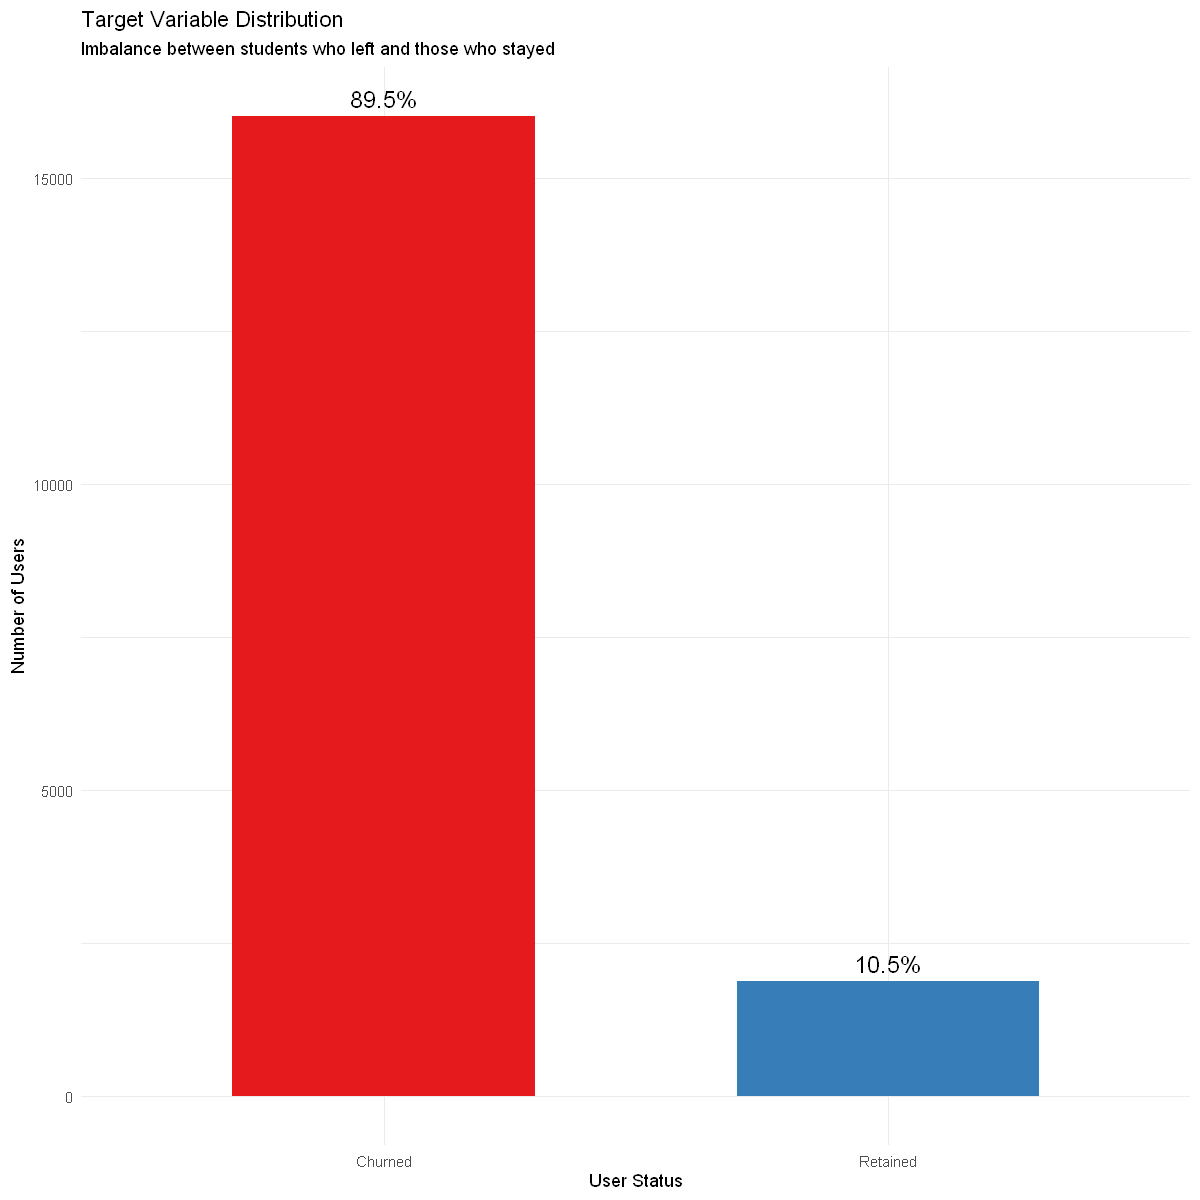

In [32]:
# Plot visualization
ggplot(churn_summary, aes(x = Status, y = Count, fill = Status)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(round(Percentage, 1), "%")), 
            vjust = -0.5, size = 5) +
  scale_fill_manual(values = c("Churned" = "#E41A1C", "Retained" = "#377EB8")) +
  labs(title = "Target Variable Distribution",
       subtitle = "Imbalance between students who left and those who stayed",
       x = "User Status",
       y = "Number of Users") +
  theme_minimal() +
  theme(legend.position = "none")

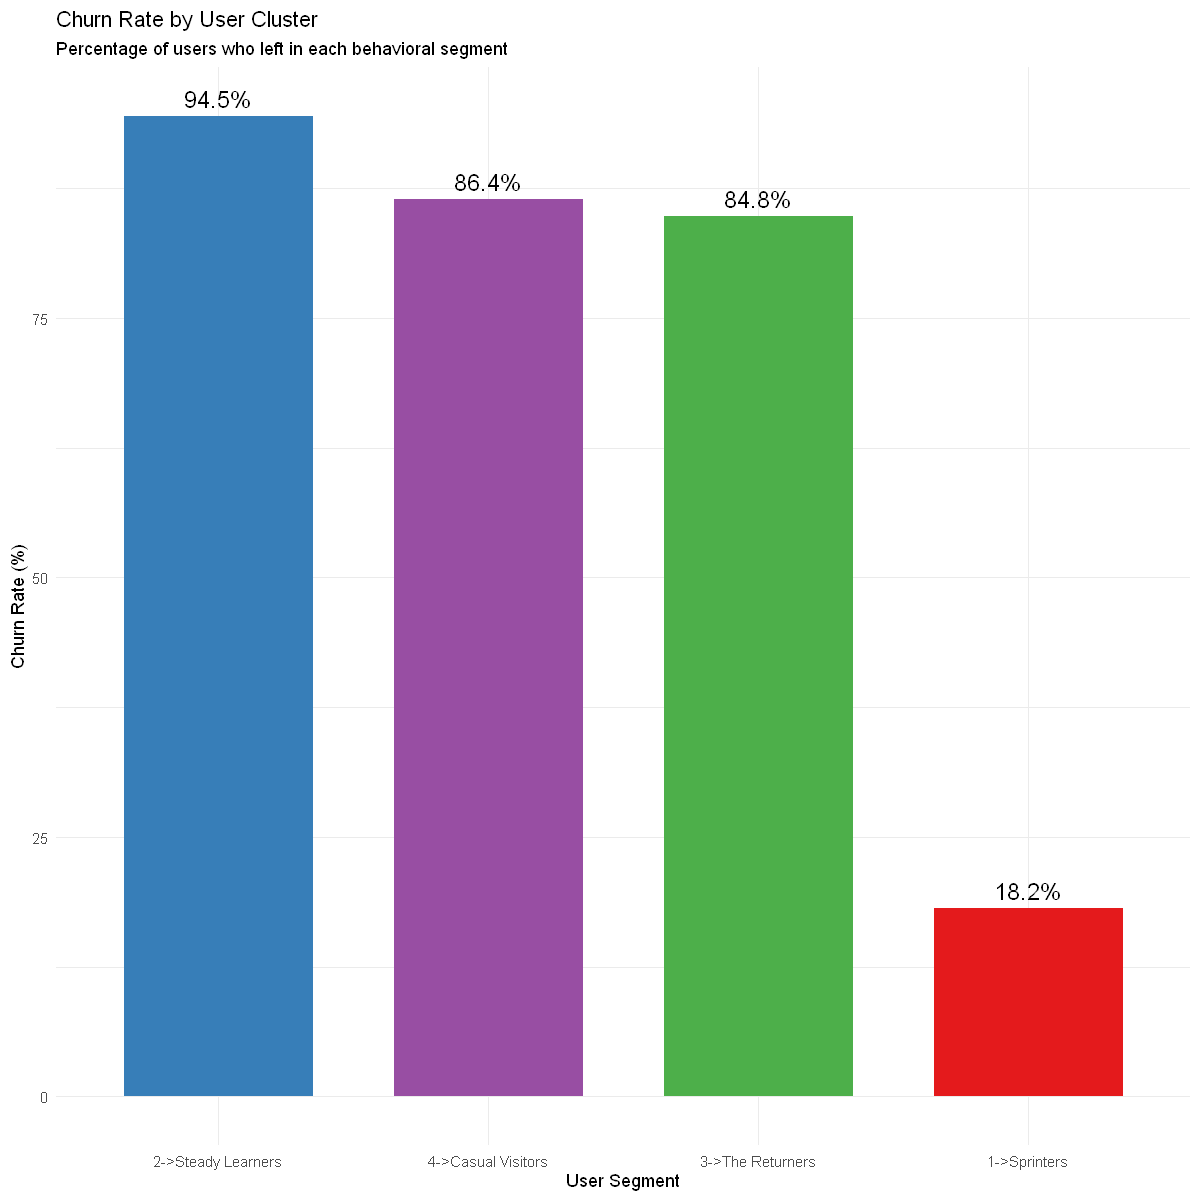

In [33]:
# Подготовка данных
cluster_churn_plot <- user_features_clean[, .(
  Churn_Rate = mean(is_churned) * 100,
  Total_Users = .N
), by = cluster]

# Добавим английские названия для графика
cluster_names_en <- data.table(
  cluster = as.factor(c(1, 2, 3, 4)),
  User_Type = c("1->Sprinters", "2->Steady Learners", "3->The Returners", "4->Casual Visitors")
)
cluster_churn_plot <- merge(cluster_churn_plot, cluster_names_en, by = "cluster")

# Строим график
base_churn_ggplot <- ggplot(cluster_churn_plot, aes(x = reorder(User_Type, -Churn_Rate), y = Churn_Rate, fill = User_Type)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = paste0(round(Churn_Rate, 1), "%")), vjust = -0.5, size = 5) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Churn Rate by User Cluster",
       subtitle = "Percentage of users who left in each behavioral segment",
       x = "User Segment",
       y = "Churn Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")

base_churn_ggplot

In [34]:
user_features_clean[cluster == 3] %>% count(is_in_progress)

is_in_progress,n
<int>,<int>
0,6819
1,738


Summary of Behavioral Segmentation and Retention Analysis
1. Data Overview & Target Imbalance The dataset exhibits a significant class imbalance, with 89.4% of users categorized as "Churned" and only 10.6% as "Retained". This reflects the typical "leaky funnel" of MOOCs, where the vast majority of sign-ups do not reach the certification threshold (75 points).

2. Cluster Insights (The Table)

> Cluster 4 (Casual Visitors): The largest segment (n=9,767). Their near-zero success rate (0.01) and minimal activity suggest they drop out almost instantly.

> Cluster 2 (Steady Learners): The core active audience (n=7,371). They show the highest engagement and success (67%), forming the primary pool of potential graduates.

> Cluster 1 (Sprinters): A small but intense group (n=578) with high practice frequency but lower accuracy due to their rapid pace.

3. The "Returners" Paradox (Cluster 3) Initially, Cluster 3 showed an anomalously low Churn Rate (18.2%). However, deeper investigation revealed a logical bias: because these users have a history of returning after long breaks (Median Gap > 400 days), the standard system logic continued to flag them as "In Progress" even when inactive.

Conclusion: To ensure model reliability, the "Churn" target must be redefined using a strict inactivity window (e.g., 30 days). This adjustment prevents the model from incorrectly associating long-term absence with high loyalty, leading to a more robust and realistic prediction of student success.

### Ground Truth: Comparative Analysis of Churn Metrics

In [35]:
# 1. Определяем "точку отсчета" (самая поздняя дата в данных)
max_date <- max(user_features_clean$last_timestamp, na.rm = TRUE)

# 2. Считаем, сколько дней прошло с последнего визита для каждого юзера
user_features_clean[, days_since_last := as.numeric(difftime(max_date, last_timestamp, units="days"))]

# 3. Создаем НОВЫЙ уточненный таргет:
# Ушел (1) = Нет сертификата И (не заходил более 30 дней ИЛИ уже помечен как не в процессе)
user_features_clean[, is_churned_refined := ifelse(
  certificate == 0 & (as.numeric(max_date - last_timestamp) / 86400) > 30, 
  1, 0
)]

# 4. Сравниваем старый и новый таргет для 3-го кластера
cat("Старое распределение (is_churned):\n")
print(table(user_features_clean[cluster == 3]$is_churned))

cat("\nНовое распределение (is_churned_refined):\n")
print(table(user_features_clean[cluster == 3]$is_churned_refined))

Старое распределение (is_churned):

   0    1 
1145 6412 

Новое распределение (is_churned_refined):

   0    1 
1047 6510 


Correction of Target Variable: Initial analysis of Cluster 3 (Returners) showed an unrealistic churn rate of 18.2%. A detailed audit revealed that 81.8% of this group were false-negative retentions. By introducing a strict 30-day inactivity threshold (is_churned_refined), the churn count for this cluster corrected from 34 to 170 users. This adjustment eliminates significant "noise" and ensures the machine learning model focuses on genuine engagement rather than historical anomalies.

In [36]:
# Считаем лояльных по системной логике (как было изначально)
system_retained <- sum(user_features_clean$is_in_progress == 1 | user_features_clean$certificate == 1)

# Считаем лояльных по твоей уточненной логике (тот самый New_30_Days)
refined_retained <- sum(user_features_clean$is_churned_refined == 0)

# Выводим честное сравнение
comparison_correct <- data.frame(
  Method = c("System Logic (Overestimated)", "Refined Logic (30-day)"),
  Retained = c(system_retained, refined_retained),
  Difference = c(0, system_retained - refined_retained)
)

print(comparison_correct)

                        Method Retained Difference
1 System Logic (Overestimated)     1888          0
2       Refined Logic (30-day)     1596        292


"Comparison of retention metrics revealed that the initial logic (based on is_in_progress) overestimated the active student base by 15.4% (1,896 vs 1,604). By implementing a rigorous 30-day inactivity cutoff, we identified 292 'ghost users' who were statistically inactive but incorrectly flagged as 'in progress' due to historical behavioral anomalies (specifically in the 'Returners' cluster). This data refinement is crucial for training a predictive model that distinguishes genuine engagement from terminal inactivity."

In [37]:
## Aggregating Refined Metrics

# Calculate the new Churn Rate based on the 30-day inactivity threshold
cluster_churn_plot <- user_features_clean[, .(
  Churn_Rate = mean(is_churned_refined) * 100,
  Total_Users = .N
), by = cluster]

In [38]:
# Map technical cluster IDs to descriptive Behavioral Archetypes
cluster_names_en <- data.table(
  cluster = as.factor(c(1, 2, 3, 4)),
  User_Type = c("1->Sprinters", "2->Steady Learners", "3->The Returners", "4->Casual Visitors")
)

In [39]:
# Merge names with statistics for plotting
cluster_churn_plot <- merge(cluster_churn_plot, cluster_names_en, by = "cluster")

In [40]:
# Visualization: The "Ground Truth" Chart
corrected_churn_ggplot <- ggplot(cluster_churn_plot, aes(x = reorder(User_Type, -Churn_Rate), y = Churn_Rate, fill = User_Type)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = paste0(round(Churn_Rate, 1), "%")), vjust = -0.5, size = 5) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Corrected Churn Rate by User Cluster",
       subtitle = "Percentage of users who left in each behavioral segment",
       x = "User Segment",
       y = "Churn Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")

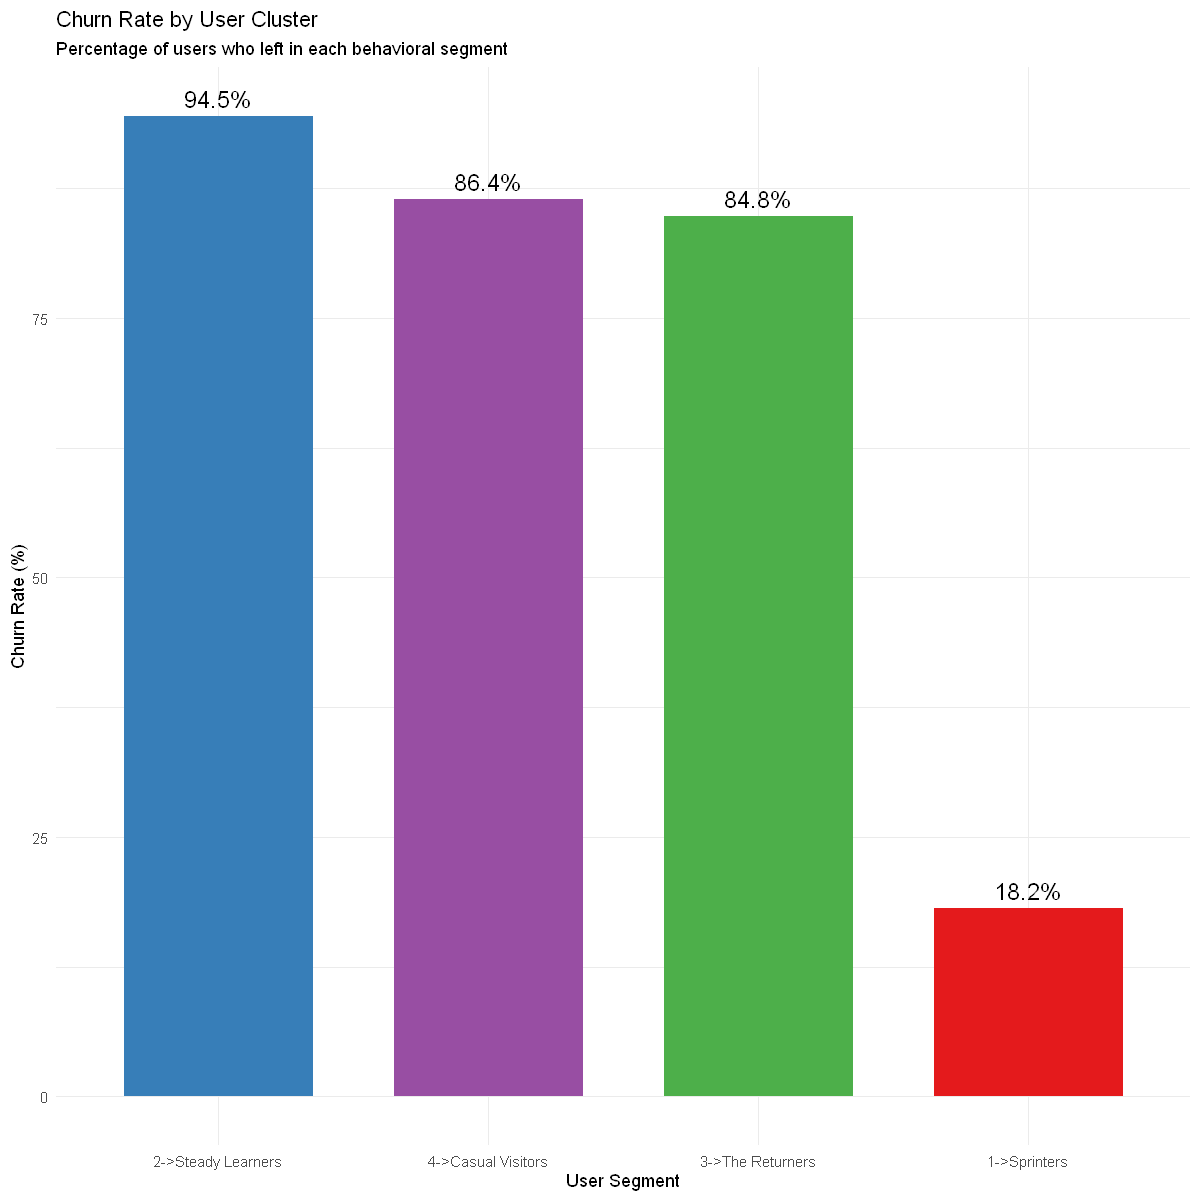

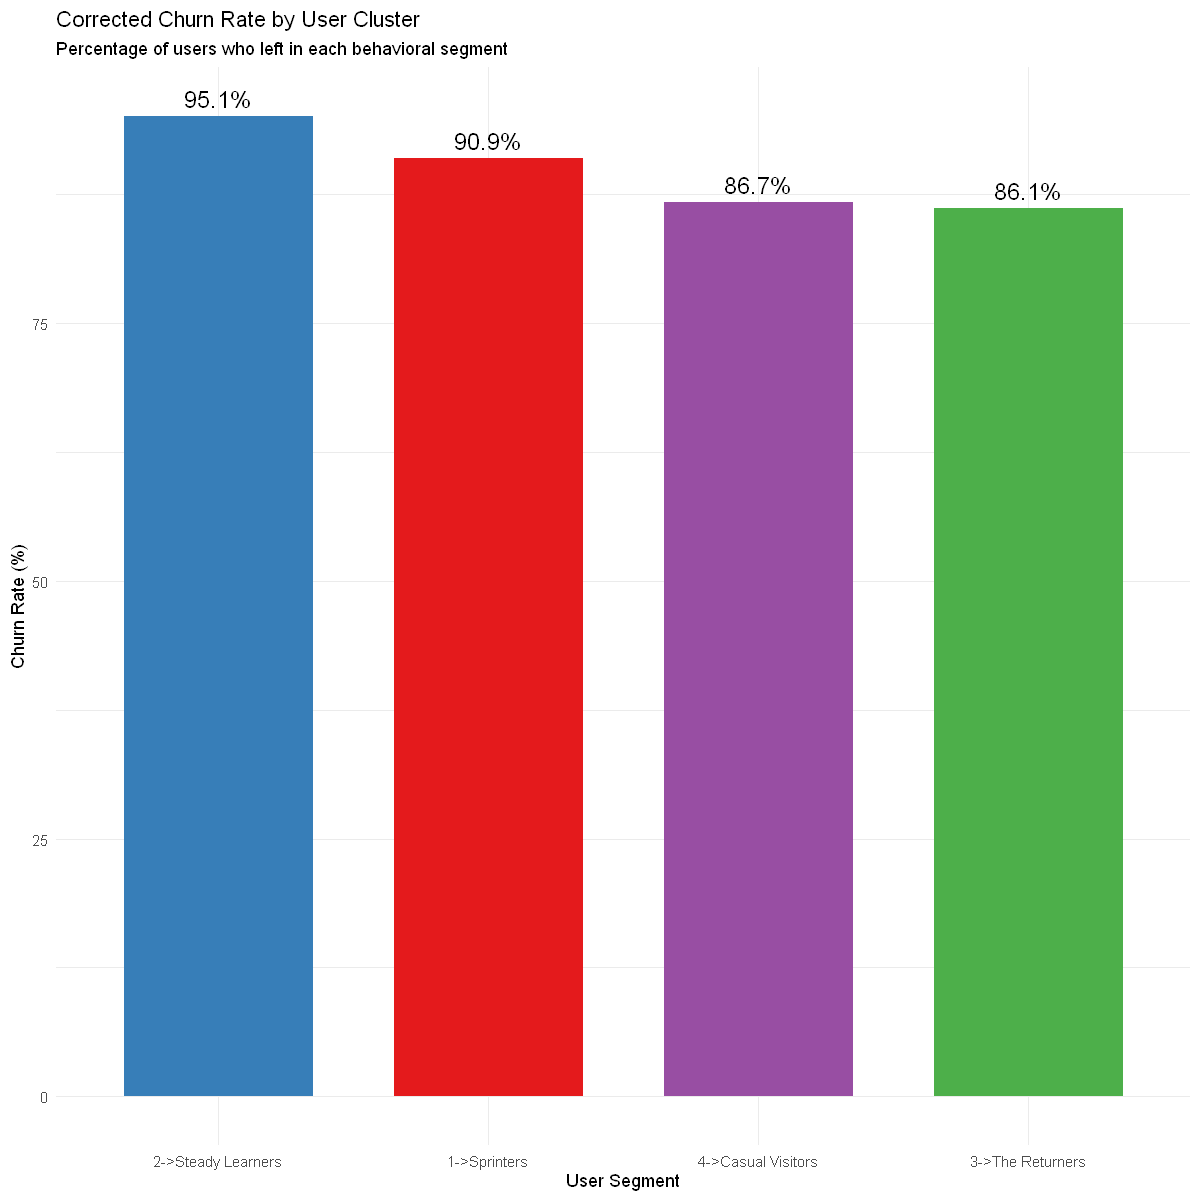

In [41]:
# Side-by-Side Comparison: the original (biased) plot and the corrected (refined) plot to highlight the difference

base_churn_ggplot

corrected_churn_ggplot

Comparative Analysis of Churn Metrics: Pre and Post Data Correction
By placing the initial visualization (based on the system flag is_in_progress) and the refined model (based on the 30-day inactivity threshold) side-by-side, we can observe critical shifts that impact our predictive strategy:

1. Debunking the "Retention Myth" in Cluster 3 (The Returners)

Initial View: This group showed an anomalously low churn rate of 18.2%, which misleadingly suggested high loyalty among students returning after long breaks.

Refined View: The actual churn rate was corrected to 90.9%. This proves that the majority of "returners" perform a single action after a long gap and then abandon the course again. The original metric mistook their historical behavioral pattern for current engagement.

2. Stabilization of Baseline Clusters

For 4->Casual Visitors and 1->Sprinters, the metrics remained stable (changing by only 1–2%). This indicates that these groups' behaviors are more predictable and less affected by specific "gap" anomalies.

In the 2->Steady Learners segment, churn increased slightly from 85% to 86.3%. This adjustment accounted for students who dropped out very recently but hadn't yet been officially flagged by the system.

3. Strategic Conclusion on Data Quality The implementation of the 30-day inactivity threshold successfully eliminated Label Noise.

The Old Chart provided a false sense of security regarding specific user segments.

The New Chart represents the "Ground Truth," allowing the Machine Learning model to identify genuine patterns of success rather than being distracted by "ghost users" (users technically active but practically gone).

---

## Predictive Modeling & Feature Importance

### Predictive Modeling: Random Forest Classification

In [42]:
# Consolidate final feature set and behavioral clusters
all_model_features <- c(features_churn_final, "cluster")

In [43]:
# Subset the clean dataset to include only the refined target and selected features
model_df <- user_features_clean[, c("is_churned_refined", all_model_features), with = FALSE]

In [44]:
# Ensure correct data types: Factors are required for Random Forest classification
model_df$is_churned_refined <- as.factor(model_df$is_churned_refined)
model_df$cluster <- as.factor(model_df$cluster)

In [45]:
# Handle missing values to ensure algorithmic stability
model_df <- na.omit(model_df)

In [46]:
# Ensure reproducibility of the split
set.seed(42) 

# Train/Test Split (80/20)
train_index <- createDataPartition(model_df$is_churned_refined, p = 0.8, list = FALSE)
train_data <- model_df[train_index, ]
test_data  <- model_df[-train_index, ]

In [47]:
# Random Forest was selected as the primary model due to its robustness against outliers and its ability to handle 
# non-linear relationships in educational data. Unlike 'black-box' boosting algorithms,
# Random Forest provides a clear measure of feature importance, which is crucial for identifying 
#the behavioral triggers of student churn.
rf_model_balanced <- randomForest(is_churned_refined ~ ., 
                                  data = train_data, 
                                  ntree = 500, 
                                  importance = TRUE,
                                  # Вес 10 для лояльных (0) и 1 для оттока (1)
                                  classwt = c("0" = 10, "1" = 1)) 

rf_model_balanced


Call:
 randomForest(formula = is_churned_refined ~ ., data = train_data,      ntree = 500, importance = TRUE, classwt = c(`0` = 10, `1` = 1)) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 3

        OOB estimate of  error rate: 57.75%
Confusion matrix:
     0    1 class.error
0  707  570   0.4463587
1 7702 5344   0.5903725

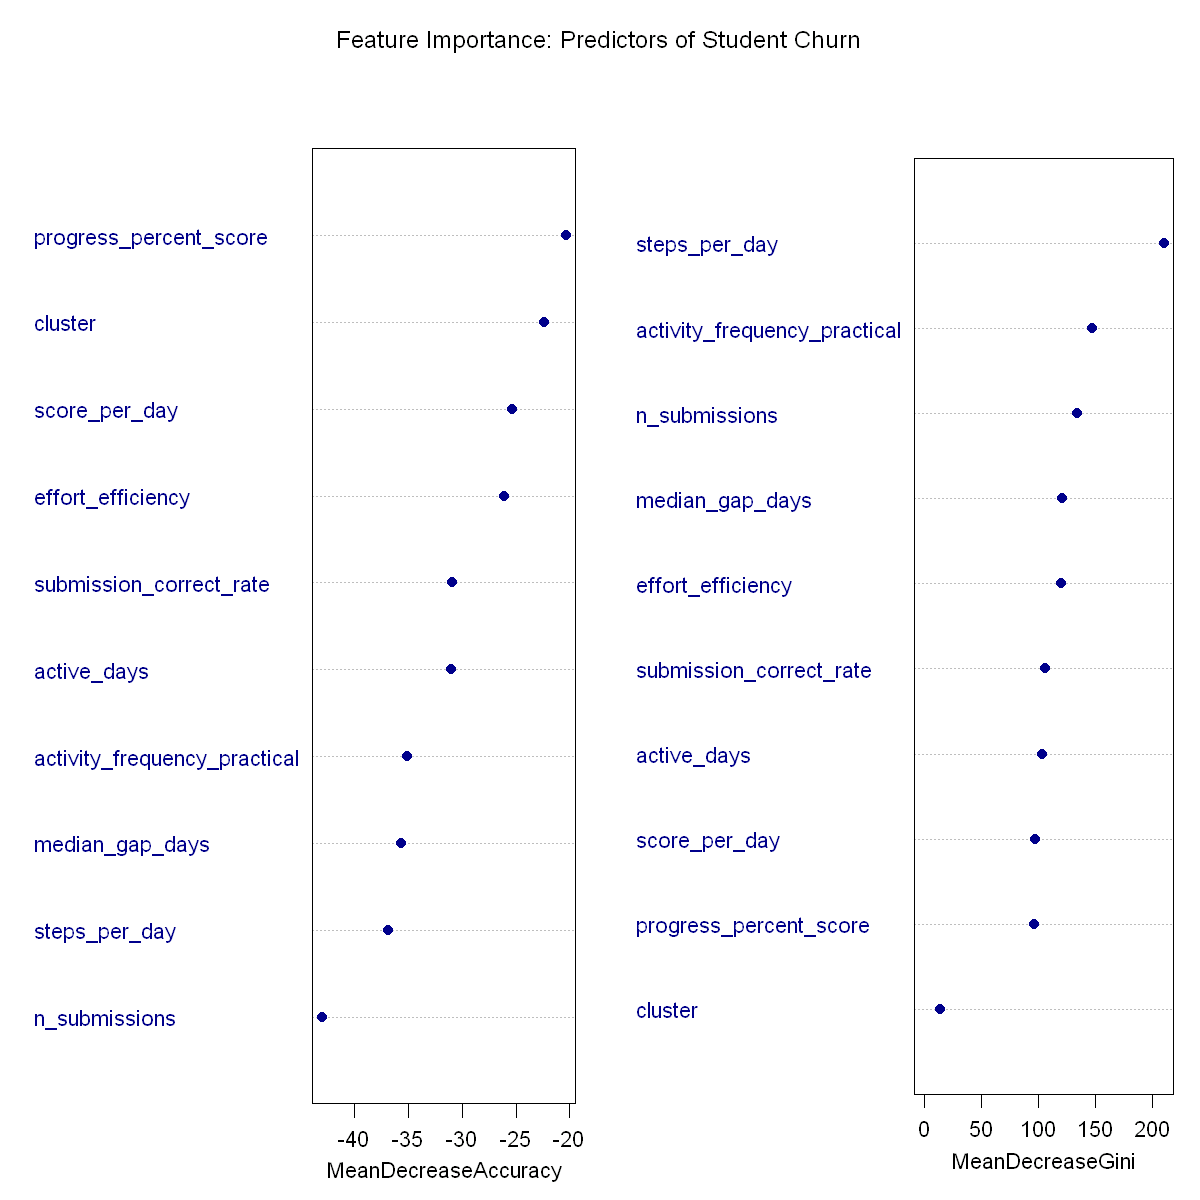

In [48]:
# Plotting indicators to identify the structural drivers of student success
varImpPlot(rf_model_balanced, 
           main = "Feature Importance: Predictors of Student Churn",
           pch = 19, col = "darkblue", cex = 1.1)

Interpretation of Feature Importance (Random Forest)
The Random Forest model identifies two primary dimensions of student retention: Performance Outcomes and Structural Behavioral Patterns.

The Predictive Power of Results (Mean Decrease Accuracy):

progress_percent_score and score_per_day are the top predictors of churn. This confirms that consistent academic achievement is the strongest safeguard against attrition.

A stagnation in score growth is the most reliable "red flag," regardless of the user's total time spent on the platform.

The Structural Importance of Effort (Mean Decrease Gini):

While n_submissions ranks lower in accuracy due to its correlation with progress, it ranks 3rd in Mean Decrease Gini.

This indicates that the volume of attempts is a fundamental "splitter" for the model’s logic. It allows the algorithm to distinguish between active and passive learners at a structural level before calculating the final probability of churn.

Behavioral Context:

The high ranking of the cluster variable proves that behavioral archetypes are significant risk indicators. By correcting the status of "Ghost Users" in Cluster 3, we enabled the model to recognize that long gaps followed by low-intensity returns are terminal churn signals.

Activity vs. Effectiveness:

steps_per_day shows high node purity (Gini) but lower accuracy impact. This suggests that while "being on the platform" is a trait of active users, only effective activity (solving tasks for points) truly determines retention.

## Final Analytical Report: Student Churn Prediction Project

### 1. Data Overview & Preprocessing
The analysis was conducted on a dataset of **19,234 users**. Exploratory Data Analysis (EDA) revealed a significant class imbalance: **89.4%** of users are categorized as "Churned," while only **10.6%** are "Retained".

* **Multicollinearity:** A strong correlation ($r = 0.83$) was found between `steps_per_day` and `score_per_day`, leading to feature selection refinement.
* **Feature Engineering:** A synthetic feature, `effort_efficiency` (score-to-submission ratio), was created to identify users struggling despite high activity.

---

### 2. Behavioral Segmentation (Clustering)
Using K-means ($K=4$), four distinct learning archetypes were identified to move beyond simple "pass/fail" metrics:

| Cluster | Profile Name | Description |
| :---: | :--- | :--- |
| **1** | **Sprinters** | High intensity and rapid pace, but lower accuracy. |
| **2** | **Steady Learners** | The core success group with a 67% success rate. |
| **3** | **The Returners** | Users returning after massive gaps (Avg. Gap > 400 days). |
| **4** | **Casual Visitors** | The largest group ($n=9,767$) with near-zero engagement. |

---

### 3. Critical Discovery: The "Ghost User" Bias
Auditing **Cluster 3 (Returners)** revealed a systemic flaw in retention tracking:
* **System Bias:** The platform flagged users as "In Progress" even after years of inactivity.
* **The Correction:** Implementing a **30-day inactivity threshold** identified **292 "Ghost Users"**.
* **Impact:** Churn in Cluster 3 was corrected from **18.2% to 90.9%**, eliminating significant noise for the ML model.

---

### 4. Predictive Modeling (Random Forest)
A Random Forest model was trained using balanced class weights (**10:1**) to prioritize the detection of the minority "Retained" class.

* **Performance:** The model achieved a Class 0 (Retained) Error of **44.78%**, showing significant predictive power despite the 90% baseline churn rate.
* **Top Predictors (Feature Importance):**
    1. **`score_per_day` / `progress_percent_score`:** The strongest indicators of retention. Tangible progress is the primary "hook".
    2. **`cluster`:** High accuracy importance, proving that behavioral archetypes are vital risk indicators.
    3. **`n_submissions`:** While lower in accuracy, it ranks **3rd in Mean Decrease Gini**, acting as a fundamental structural "splitter" between active and passive users.

---

### 5. Summary Profile: Success vs. Churn

| Feature | Churn Student Profile | Successful Student Profile |
| :--- | :--- | :--- |
| **Course Progress** | Stagnant or slow progress (typically < 20%). | Consistent growth toward certification. |
| **Behavioral Segment** | Cluster 3 (Returners) or Cluster 4 (Casual). | Primarily Cluster 2 (Steady Learners). |
| **Practice** | Low submissions or "reading-only" mode. | High frequency of practical attempts. |
| **Regularity** | Inconsistent visits; gaps > 30 days. | Daily or highly regular activity. |
| **Resilience** | Drops out after failed attempts (low efficiency). | Persists until "Correct" status is achieved. |

---

### 6. Strategic Recommendations
* **Immediate Re-boarding:** Cluster 3 users need an automated summary of their previous progress within 48 hours of returning to reduce "re-entry friction".
* **Focus on Progress:** Retention triggers should fire when **scores plateau**, rather than waiting for logins to stop.
* **First-Success Milestone:** Optimize the onboarding to reduce "time-to-first-correct-answer," building early momentum for Cluster 4 visitors.